# E1 — GPU-ready visual world-model pilot

**TL;DR.** This notebook validates the complete learned-representation interface on a tiny real
pixel dataset: deterministic trajectory-level splits, hidden-velocity RGB histories, analytic
safety/action labels, AE or beta-VAE construction, latent transition, safety heads, and a finite
forward/backward optimization step. It also materializes the exact 96-task two-domain decision
pilot and shows how to launch one task or a Slurm array. The persisted outputs are engineering evidence only;
one epoch, one batch, or a selected seed is not an ICML result.

The full command-line trainer additionally writes hashed checkpoints, rollout metrics, calibration
and test audit records, and failure-aware manifests. This notebook is generated by
`scripts/build_notebooks.py`.

## Assumptions and experiment boundary

- The notebook visualizes the controlled cart; a separate controlled-pendulum config exercises the
  same interface. These are two synthetic dynamics, not yet a broad confirmatory benchmark suite.
  A single frame hides velocity; two or four frames can reveal it.
- `h = position_limit - |position|`. The safe-action profile is a declared finite action grid and
  finite nominal horizon, not a continuous-action viability kernel.
- `stack_h1` and `stack_h4` share a fixed-width `(last, last-first)` feature summary and therefore
  the same model parameter count; the latter alone receives nonzero temporal-difference input.
- Checkpoints are selected using validation **world-model utility only**. Test safety labels never
  choose epochs, radii, weights, or architectures.
- The pilot uses three paired seeds and is exploratory. The confirmatory protocol still requires
  eight paired seeds on selected arms after the estimator and prevalence gates pass.

In [1]:
from itertools import product
from pathlib import Path
import dataclasses
import json
import os
import shlex
import subprocess
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.learning import (
    build_datasets,
    build_world_model,
    cpu_smoke_config,
    dry_run_plan,
    generate_trajectories,
    load_config,
    render_state,
    require_torch,
)
from latent_safety.learning.losses import boundary_contrastive_loss, compute_losses

CONFIG_PATH = ROOT / "configs" / "e1_world_models" / "torch_pilot.toml"
base_config = load_config(CONFIG_PATH)
smoke_config = cpu_smoke_config(base_config)
plan = dry_run_plan(smoke_config)
display(plan)
assert plan["torch_required"] is False
assert set(plan["trajectory_counts"]) == {"train", "validation", "calibration", "test"}
assert all(count > 0 for count in plan["trajectory_counts"].values())

{'schema_version': 1,
 'experiment': 'e1_controlled_cart_beta_vae_safe_action_pilot',
 'status': 'smoke_test_only',
 'task': 'controlled_cart_video',
 'torch_required': False,
 'selected_arm': 'safe_action_profile',
 'representation': {'family': 'beta_vae',
  'history_mode': 'gru_h2',
  'history_encoder': 'gru',
  'history_length': 2,
  'latent_dim': 4},
 'trajectory_counts': {'train': 10,
  'validation': 2,
  'calibration': 2,
  'test': 2},
 'sample_counts': {'train': 100,
  'validation': 20,
  'calibration': 20,
  'test': 20},
 'total_samples': 160,
 'pixels_per_history': 1536,
 'approx_batch_input_mib': 0.094,
 'rollout_horizons': [1, 2],
 'requested_device': 'cpu',
 'deterministic': True,
 'fcsrl': None}

## 1. Inspect the deterministic visual benchmark before touching the model

{'trajectories': 16,
 'split_trajectory_counts': {'train': 10,
  'validation': 2,
  'calibration': 2,
  'test': 2},
 'frames': 160,
 'unsafe_frame_fraction': 0.11875,
 'action_profile_variation_fraction': 0.94375}

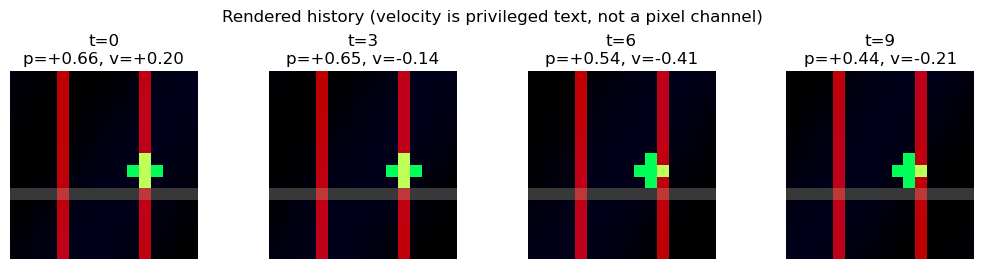

In [2]:
trajectories = generate_trajectories(smoke_config.data, seed=smoke_config.run.seed)
split_counts = {
    split: sum(trajectory.split == split for trajectory in trajectories)
    for split in ("train", "validation", "calibration", "test")
}
all_margins = [margin for trajectory in trajectories for margin in trajectory.safety_margins]
unsafe_fraction = sum(margin < 0.0 for margin in all_margins) / len(all_margins)
profile_variation_fraction = np.mean([
    max(profile) - min(profile) > 1e-6
    for trajectory in trajectories
    for profile in trajectory.action_safety_margins
])

data_summary = {
    "trajectories": len(trajectories),
    "split_trajectory_counts": split_counts,
    "frames": len(all_margins),
    "unsafe_frame_fraction": unsafe_fraction,
    "action_profile_variation_fraction": float(profile_variation_fraction),
}
display(data_summary)
assert unsafe_fraction > 0.0, "the smoke fixture must include unsafe examples"
assert profile_variation_fraction > 0.0, "actions must differ in safety somewhere"

trajectory = trajectories[0]
frame_indices = (0, 3, 6, 9)
fig, axes = plt.subplots(1, len(frame_indices), figsize=(10.5, 2.7))
for axis, frame_index in zip(axes, frame_indices, strict=True):
    flat = render_state(trajectory.states[frame_index], smoke_config.data)
    channel_first = np.asarray(flat).reshape(
        smoke_config.data.channels,
        smoke_config.data.image_size,
        smoke_config.data.image_size,
    )
    image = np.moveaxis(channel_first, 0, -1)
    axis.imshow(image, vmin=0.0, vmax=1.0)
    axis.set_title(
        f"t={frame_index}\np={trajectory.states[frame_index].position:+.2f}, "
        f"v={trajectory.states[frame_index].velocity:+.2f}"
    )
    axis.axis("off")
fig.suptitle("Rendered history (velocity is privileged text, not a pixel channel)")
fig.tight_layout()
plt.show()

## 2. Real PyTorch forward/backward integration check

This imports PyTorch only here, builds all four dataset splits and the configured beta-VAE/GRU
world model, and performs one optimizer step on a real RGB history batch. It checks tensor shapes,
finite objectives, nonzero gradients, and evaluation-latent determinism. It deliberately does not
interpret the one-batch loss as model quality.

In [3]:
modules = require_torch()
torch = modules.torch
torch.manual_seed(smoke_config.run.seed)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
bundle = build_datasets(
    smoke_config.data,
    seed=smoke_config.run.seed,
    torch=torch,
)
loader = torch.utils.data.DataLoader(
    bundle.datasets["train"],
    batch_size=smoke_config.run.batch_size,
    shuffle=False,
    num_workers=0,
)
batch = next(iter(loader))
model = build_world_model(modules, smoke_config.model, smoke_config.data)
model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=smoke_config.run.learning_rate)
optimizer.zero_grad(set_to_none=True)
outputs = model(batch["history"], batch["action"])
with torch.no_grad():
    target_latent = model.encode(batch["next_history"], sample=False)["z"]
losses = compute_losses(
    modules,
    outputs,
    target_latent,
    batch,
    smoke_config.objective,
)
assert all(bool(torch.isfinite(value).item()) for value in losses.values())
losses["total"].backward()
gradient_norm = torch.sqrt(sum(
    parameter.grad.detach().square().sum()
    for parameter in model.parameters()
    if parameter.grad is not None
))
assert float(gradient_norm) > 0.0
optimizer.step()

model.eval()
with torch.no_grad():
    first_mean = model.encode(batch["history"], sample=False)["mean"]
    second_mean = model.encode(batch["history"], sample=False)["mean"]
assert torch.equal(first_mean, second_mean)
assert tuple(batch["history"].shape[1:]) == (
    smoke_config.data.history_length,
    smoke_config.data.channels,
    smoke_config.data.image_size,
    smoke_config.data.image_size,
)
assert outputs["predicted_action_profile"].shape[-1] == len(smoke_config.data.actions)

integration_summary = {
    "torch": str(torch.__version__),
    "cuda_available_here": bool(torch.cuda.is_available()),
    "dataset_manifest_sha256": bundle.manifest_sha256,
    "train_samples": len(bundle.datasets["train"]),
    "batch_history_shape": list(batch["history"].shape),
    "latent_shape": list(outputs["mean"].shape),
    "parameter_count": sum(parameter.numel() for parameter in model.parameters()),
    "gradient_norm": float(gradient_norm),
    "losses": {name: float(value.detach()) for name, value in losses.items()},
}
display(integration_summary)

# Capacity audit for the primary memoryless-versus-history comparison.
stack_model_config = dataclasses.replace(smoke_config.model, history_encoder="stack")
stack_counts = {}
for history_length in (1, 4):
    data_config = dataclasses.replace(smoke_config.data, history_length=history_length)
    comparison_model = build_world_model(modules, stack_model_config, data_config)
    stack_counts[f"stack_h{history_length}"] = sum(
        parameter.numel() for parameter in comparison_model.parameters()
    )
assert stack_counts["stack_h1"] == stack_counts["stack_h4"]
display({"capacity_matched_stack_parameter_counts": stack_counts})

probe_latent = torch.tensor(
    [[1.0, 0.2], [-0.4, 1.0], [0.7, -0.8], [-0.9, -0.3]],
    dtype=torch.float32,
)
probe_margin = torch.tensor([0.10, -0.10, 0.03, -0.03], dtype=torch.float32)
base_boundary_loss = boundary_contrastive_loss(
    modules, probe_latent, probe_margin, smoke_config.objective
)
rescaled_boundary_loss = boundary_contrastive_loss(
    modules, 1000.0 * probe_latent, probe_margin, smoke_config.objective
)
assert torch.allclose(base_boundary_loss, rescaled_boundary_loss, atol=1e-7, rtol=1e-7)
display({
    "unit_normalized_boundary_loss": float(base_boundary_loss),
    "loss_after_1000x_code_rescaling": float(rescaled_boundary_loss),
})

{'torch': '2.10.0',
 'cuda_available_here': False,
 'dataset_manifest_sha256': 'b2fcd14d6da722bcf4c78619fb170572ad7da74142e090dd5d3d125df62988c0',
 'train_samples': 100,
 'batch_history_shape': [8, 2, 3, 16, 16],
 'latent_shape': [8, 4],
 'parameter_count': 295331,
 'gradient_norm': 0.7434505224227905,
 'losses': {'total': 0.40051543712615967,
  'reconstruction': 0.2090960294008255,
  'transition': 0.03579407185316086,
  'kl': 0.03428041934967041,
  'safety': 0.3112163841724396}}

{'capacity_matched_stack_parameter_counts': {'stack_h1': 291139,
  'stack_h4': 291139}}

{'unit_normalized_boundary_loss': 0.0, 'loss_after_1000x_code_rescaling': 0.0}

## 3. Optional end-to-end smoke with manifests

The command below trains one epoch and evaluates every split. It is skipped by default because it
writes an ignored run directory. To run it during notebook execution, set
`LATENT_SAFETY_NOTEBOOK_E2E=1` and optionally `LATENT_SAFETY_NOTEBOOK_OUTPUT` to a new, empty path.
The trainer refuses to overwrite a nonempty run directory.

In [4]:
run_e2e = os.environ.get("LATENT_SAFETY_NOTEBOOK_E2E") == "1"
e2e_output = Path(os.environ.get(
    "LATENT_SAFETY_NOTEBOOK_OUTPUT",
    "runs/e1_world_models/notebook_cpu_smoke",
))
e2e_command = [
    sys.executable,
    str(ROOT / "scripts" / "run_e1_torch.py"),
    "--config",
    str(CONFIG_PATH),
    "--smoke",
    "--output",
    str(e2e_output),
]
if run_e2e:
    subprocess.run(e2e_command, cwd=ROOT, check=True)
else:
    print("Skipped write-producing E2E run. Command:")
    portable_e2e_command = [
        "python",
        "scripts/run_e1_torch.py",
        "--config",
        CONFIG_PATH.relative_to(ROOT).as_posix(),
        "--smoke",
        "--output",
        e2e_output.as_posix(),
    ]
    print(shlex.join(portable_e2e_command))

Skipped write-producing E2E run. Command:
python scripts/run_e1_torch.py --config configs/e1_world_models/torch_pilot.toml --smoke --output runs/e1_world_models/notebook_cpu_smoke


## 4. Pre-registered paired decision pilot

The first GPU gate is exactly `2 domains × 2 model families × 2 capacity-matched history modes ×
1 latent dimension × 4 safety arms × 3 paired seeds = 96` tasks. `stack_h1` is the true memoryless
control and `stack_h4` adds four-frame information without changing the fixed-width stack model's
parameter count. Every task records its domain, history mode, encoder, and length and has a unique
output directory. The three-seed grid is exploratory; only validation utility and a predeclared
Pareto rule may authorize an eight-seed confirmatory stage.

The checked-in 288-task full expansion adds `gru_h4` and latent dimension 4 only after the decisive
pilot passes. Each domain is analyzed first on its own; domain is not treated as another seed.

In [5]:
families = ("ae", "beta_vae")
history_modes = {
    "stack_h1": ("stack", 1),
    "stack_h4": ("stack", 4),
}
latent_dimensions = (8,)
safety_arms = ("none", "h_prediction", "boundary_contrastive", "safe_action_profile")
seeds = (0, 1, 2)
domains = {
    "cart": "configs/e1_world_models/torch_pilot.toml",
    "pendulum": "configs/e1_world_models/torch_pendulum_pilot.toml",
}
pilot_commands = []
for domain, family, history_mode, dimension, arm, seed in product(
    domains, families, history_modes, latent_dimensions, safety_arms, seeds
):
    history_encoder, history_length = history_modes[history_mode]
    output = (
        Path("runs") / "e1_world_models" / f"decisive_{domain}_grid"
        / f"{family}_{history_mode}_d{dimension}" / arm / f"seed_{seed}"
    )
    command = [
        "python",
        "scripts/run_e1_torch.py",
        "--config", domains[domain],
        "--output", str(output),
        "--device", "cuda",
        "--seed", str(seed),
        "--model-family", family,
        "--history-encoder", history_encoder,
        "--history-length", str(history_length),
        "--latent-dim", str(dimension),
        "--safety-arm", arm,
    ]
    pilot_commands.append(command)

assert len(pilot_commands) == 96
assert len({command[command.index("--output") + 1] for command in pilot_commands}) == 96
display({
    "task_count": len(pilot_commands),
    "domains": domains,
    "history_modes": history_modes,
    "paired_seeds": list(seeds),
    "first_four_commands": [shlex.join(command) for command in pilot_commands[:4]],
})

{'task_count': 96,
 'domains': {'cart': 'configs/e1_world_models/torch_pilot.toml',
  'pendulum': 'configs/e1_world_models/torch_pendulum_pilot.toml'},
 'history_modes': {'stack_h1': ('stack', 1), 'stack_h4': ('stack', 4)},
 'paired_seeds': [0, 1, 2],
 'first_four_commands': ['python scripts/run_e1_torch.py --config configs/e1_world_models/torch_pilot.toml --output runs/e1_world_models/decisive_cart_grid/ae_stack_h1_d8/none/seed_0 --device cuda --seed 0 --model-family ae --history-encoder stack --history-length 1 --latent-dim 8 --safety-arm none',
  'python scripts/run_e1_torch.py --config configs/e1_world_models/torch_pilot.toml --output runs/e1_world_models/decisive_cart_grid/ae_stack_h1_d8/none/seed_1 --device cuda --seed 1 --model-family ae --history-encoder stack --history-length 1 --latent-dim 8 --safety-arm none',
  'python scripts/run_e1_torch.py --config configs/e1_world_models/torch_pilot.toml --output runs/e1_world_models/decisive_cart_grid/ae_stack_h1_d8/none/seed_2 --devic

## 5. High-GPU launch and post-training audit

From the repository root, generate the immutable task plan and submit the array:

```bash
python scripts/plan_e1_sweep.py \
  --grid configs/e1_world_models/decisive_cart_grid.toml \
  --output runs/plans/e1_decisive_cart.json
python scripts/plan_e1_sweep.py \
  --grid configs/e1_world_models/decisive_pendulum_grid.toml \
  --output runs/plans/e1_decisive_pendulum.json
mkdir -p runs/slurm
sbatch experiments/e1_world_models/slurm_decisive_cart_array.sh
sbatch experiments/e1_world_models/slurm_decisive_pendulum_array.sh
```

For a workstation, run one indexed task without shell-generated commands:

```bash
python scripts/run_e1_sweep_task.py \
  --plan runs/plans/e1_decisive_cart.json --index 0 --device cuda
```

Then audit the frozen test codes at radii scaled using **calibration codes only**:

```bash
python scripts/audit_e1_records.py \
  --config configs/e1_world_models/torch_pilot.toml \
  --calibration runs/.../audit_calibration.jsonl \
  --test runs/.../audit_test.jsonl \
  --output runs/.../latent_safety_audit.json \
  --relative-radii 0 0.01 0.02 0.05 0.10
```

These relative radii are a scale-equivariant diagnostic convention, not a deployment
certificate. A paper guarantee needs a physical uncertainty set or verified set propagation.

## Takeaways and next decision

The visual data/model interface passes a genuine in-memory PyTorch gradient-step check, and the
96-task two-domain decision pilot is fully specified with unique outputs and paired seeds. The command-line path can
also run one CPU epoch end to end and emit provenance-complete artifacts.

**Readiness:** engineering-ready for a small GPU pilot, not evidence-ready for the manuscript. The
next scientific decision is whether ordinary and safety-aware encoders separate on the calibrated
static/action curves at matched validation world-model utility. If the effect vanishes under
history encoders, trajectory splits, or observation-level controls, the project should pivot to a
narrower dynamic-theory or control-venue contribution rather than scale the grid.